In [2]:
from skyfield.api import load
import matplotlib.pyplot as plt

In [4]:
# Load active satellite TLE data
tle_url = "https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle"
satellites = load.tle_file(tle_url)


# Select Sentinel-1A
by_name = {sat.name: sat for sat in satellites}
sentinel = by_name["SENTINEL-1A"]


# Timescale
ts = load.timescale()


# Reference location - latitude, longitude of Aarhus
ground_lat = 56.1567
ground_lon = 10.2108

[#################################] 100% gp.php


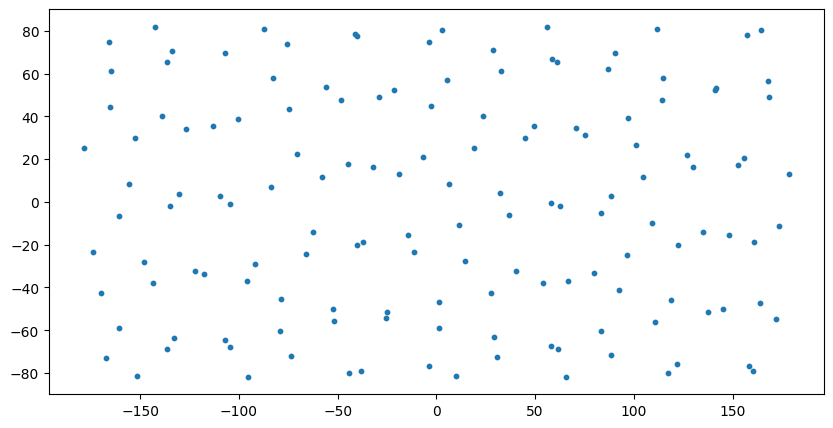

In [5]:
# Generate times for one full day (every 10 minutes)
# give today's date - 2026, 1, 27
times = ts.utc(2026, 1, 27, 0, range(0, 24 * 60, 10))


# TODO: Compute satellite positions - check skyfield mini reference
positions = sentinel.at(times)


# TODO: Compute satellite positions - check skyfield mini reference
# TODO: Extract latitude and longitude in degrees 
lats = positions.subpoint().latitude.degrees
lons = positions.subpoint().longitude.degrees

plt.figure(figsize=(10, 5))
plt.scatter(lons, lats, s=10)
plt.show()

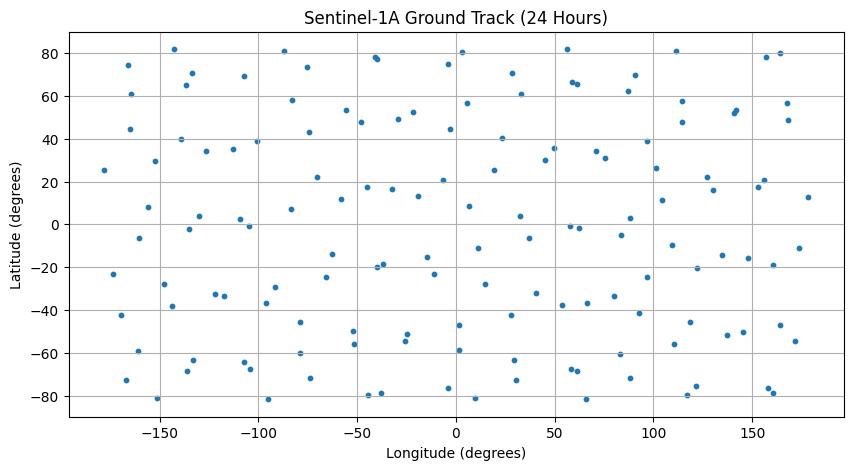

In [6]:
plt.figure(figsize=(10, 5))


plt.scatter(lons, lats, s=10)


# TODO: Add a title
plt.title("Sentinel-1A Ground Track (24 Hours)")


# TODO: Label axes
plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")


# TODO: Add a grid
plt.grid(True)

plt.show()

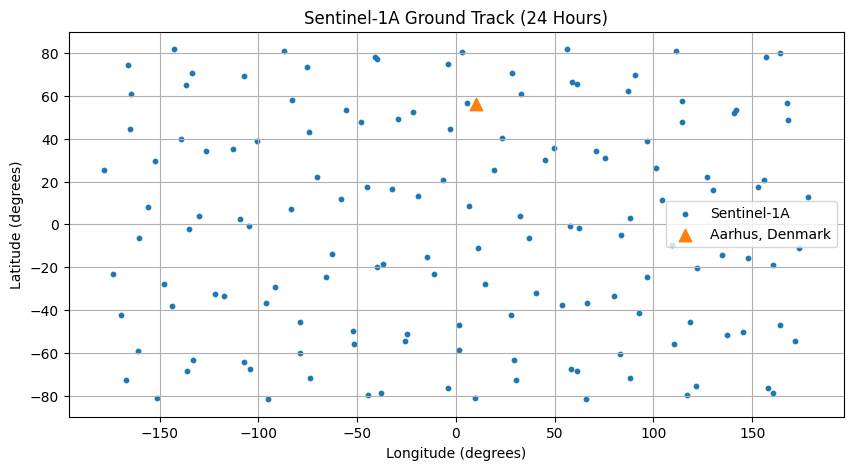

In [8]:
plt.figure(figsize=(10, 5))
plt.title("Sentinel-1A Ground Track (24 Hours)")

plt.scatter(lons, lats, s=10, label="Sentinel-1A")

# TODO: Plot Aarhus as a triangle
plt.scatter(ground_lon, ground_lat, s=80, marker="^", label="Aarhus, Denmark")

plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.grid(True)
plt.legend()
plt.show()

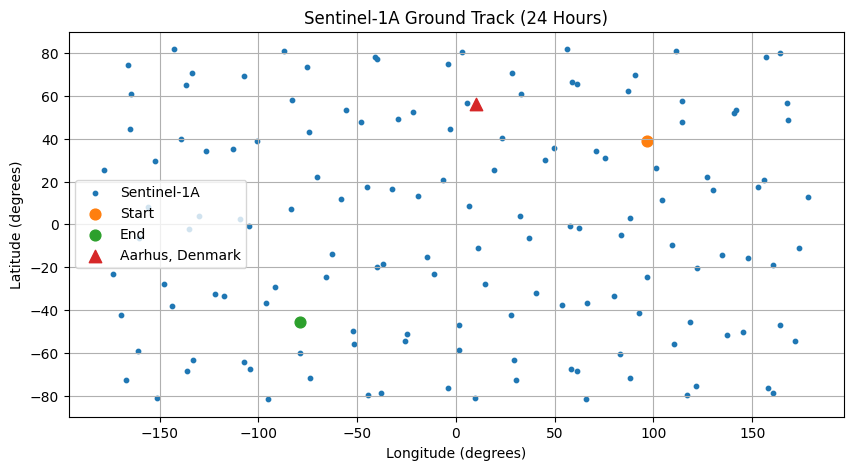

In [9]:
plt.figure(figsize=(10, 5))
plt.title("Sentinel-1A Ground Track (24 Hours)")

plt.scatter(lons, lats, s=10, label="Sentinel-1A")

# TODO: Mark the start point
plt.scatter(lons[0], lats[0], s=60, label="Start")

# TODO: Mark the end point
plt.scatter(lons[-1], lats[-1], s=60, label="End")

plt.scatter(ground_lon, ground_lat, s=80, marker="^", label="Aarhus, Denmark")

plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.grid(True)
plt.legend()
plt.show()

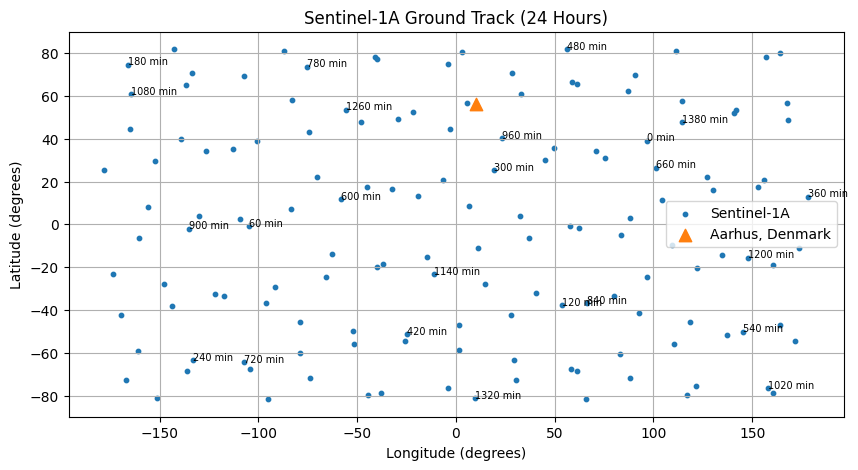

In [10]:
plt.figure(figsize=(10, 5))
plt.title("Sentinel-1A Ground Track (24 Hours)")

plt.scatter(lons, lats, s=10, label="Sentinel-1A")
plt.scatter(ground_lon, ground_lat, s=80, marker="^", label="Aarhus, Denmark")

# TODO: Add labels every hour (we will not add labels for all plots, only for every hour
for i in range(0, len(lats), 6):
    plt.text(lons[i], lats[i], f"{i*10} min", fontsize=7)

plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.grid(True)
plt.legend()
plt.show()